# **Simulación Numérica de la Ecuación de Calor 2D con Condiciones Mixtas.**
Este notebook aborda la resolución numérica del siguiente problema de difusión de temperatura en dos dimensiones:

$$
T_{tt} - 0.01(T_{xx} - T_{yy}) = 0, \quad T = T(x,y,t), \quad 0 < x < 1, \quad 0 < y < 1, \quad t > 0
$$

**Condiciones de Frontera (CF):**
- $ \frac{\partial T}{\partial x}(0, y, t) = 0 $  (Neumann en $x=0$)
- $ \frac{\partial T}{\partial y}(1, y, t) = 0 $  (Neumann en $y=1$)
- $ T(x, 0, t) = 20 $  (Dirichlet en $y=0$)
- $ T(x, 1, t) = 50 $  (Dirichlet en $y=1$)

**Condición Inicial (CI):**
$$
T(x, y, 0) = -50 \cos\left(\frac{\pi}{2}x\right) \cos\left(\frac{\pi}{2}y\right)
$$

**Objetivo:**
- Resolver la evolución temporal (**solución transitoria**) utilizando métodos explícitos e implícitos, incluyendo análisis de convergencia espacial y temporal.
- Calcular la **solución estacionaria** mediante métodos iterativos e implícitos, con y sin matrices dispersas (**sparse**).
- Presentar los resultados a través de representaciones gráficas de la distribución de temperatura y del análisis de estabilidad y precisión de los métodos empleados.

El trabajo incluirá además una comparación de mallados, análisis de la estabilidad numérica en función de $ \lambda $ y un enfoque en la optimización computacional usando matrices sparse.

## **Introducción.**
**Definición del problema.** En este trabajo se resuelve numéricamente el siguiente problema de difusión de temperatura en dos dimensiones:
$$
T_{tt} - 0.01(T_{xx} - T_{yy}) = 0, \quad T = T(x, y, t), \quad 0 < x < 1, \quad 0 < y < 1, \quad t > 0
$$

dónde $T$ representa la temperatura, $x$ y $y$ son las coordenadas espaciales y $t$ es el tiempo.

**Condiciones iniciales y de frontera.**
- **Condición Inicial (CI):**
$$
T(x, y, 0) = -50 \cos\left( \frac{\pi}{2} x \right) \cos\left( \frac{\pi}{2} y \right)
$$
- **Condiciones de Frontera (CF):**
    - $\frac{\partial T}{\partial x}(0, y, t) = 0$  (Neumann en $x=0$)
    - $\frac{\partial T}{\partial y}(1, y, t) = 0$  (Neumann en $y=1$)
    - $T(x, 0, t) = 20$  (Dirichlet en $y=0$)
    - $T(x, 1, t) = 50$  (Dirichlet en $y=1$)

**Parámetros físicos y de simulación.** Se trabajará sobre una región cuadrada $(x,y) \in (0,1) \times (0,1)$ durante un intervalo de tiempo $t > 0$. El coeficiente de difusión efectivo es $0.01$.

## **Configuración Inicial.**
En este apartado se procederá a la importación de las librerías necesarias para la ejecución del taller, las cuales han sido previamente definidas en el archivo **`requirements.txt`**. Esto garantiza la compatibilidad del entorno de trabajo y permite realizar de manera eficiente el procesamiento de datos, el cálculo de métricas estadísticas y la visualización de resultados, asegurando así una correcta ejecución de los ejercicios posteriores.

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve
import pandas as pd


pd.set_option('display.max_colwidth', None)

In [25]:
# Parámetros físicos
alpha = 0.01        # Coeficiente de difusión.

# Dimensiones del dominio
Lx = 1.0            # Longitud en x.
Ly = 1.0            # Longitud en y.

# Discretización espacial
Nx = 20             # Número de nodos en x.
Ny = 20             # Número de nodos en y.
dx = Lx / (Nx - 1)  # Paso en x.
dy = Ly / (Ny - 1)  # Paso en y.

# Discretización temporal.
dt = 0.0005         # Paso temporal.
T_max = 0.1         # Tiempo máximo de simulación.
Nt = int(T_max / dt)  # Número de pasos de tiempo.

# Parámetro de estabilidad (solo relevante para método explícito).
lambda_x = alpha * dt / (dx**2)
lambda_y = alpha * dt / (dy**2)

print(f"lambda_x = {lambda_x:.5f}, lambda_y = {lambda_y:.5f}")

lambda_x = 0.00181, lambda_y = 0.00181


In [26]:
# Malla espacial
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y)

## **Solución Transitoria.**
En esta sección se resuelve la evolución temporal de la temperatura, es decir, cómo cambia $ T(x, y, t) $ con el tiempo.

Se utilizarán distintos métodos numéricos para aproximar la solución:
- Método explícito.
- Método implícito.
- Método implícito usando matrices sparse.

En cada método se implementará la discretización temporal y espacial, se simulará la evolución durante un intervalo de tiempo dado y se representarán los resultados.

Además, se realizará un análisis de convergencia para comprobar la estabilidad y precisión de los métodos según el mallado espacial y los parámetros de tiempo.

El objetivo es obtener la distribución de temperaturas en varios instantes $t$ y observar su evolución hacia el estado estacionario.

### **Método Explícito.**

In [27]:
# Función: condición inicial
def initial_condition():
    return np.zeros((Nx, Ny))

# Función: aplicar condiciones de frontera
def apply_boundary_conditions(T):
    T[:, 0] = 20         # y = 0 (Dirichlet)
    T[:, -1] = 50        # y = Ly (Dirichlet)
    T[0, :] = T[1, :]    # x = 0 (Neumann)
    T[-1, :] = T[-2, :]  # x = Lx (Neumann)
    return T

# Función: método explícito
def metodo_explicito():
    T = initial_condition()
    lambda_x = alpha * dt / dx**2
    lambda_y = alpha * dt / dy**2
    T = apply_boundary_conditions(T)

    resultados = {}
    pasos = [0, int(Nt/3), int(2*Nt/3), Nt-1]

    for n in range(Nt):
        T_new = T.copy()
        for i in range(1, Nx - 1):
            for j in range(1, Ny - 1):
                T_new[i, j] = (
                    T[i, j]
                    + lambda_x * (T[i+1, j] - 2*T[i, j] + T[i-1, j])
                    + lambda_y * (T[i, j+1] - 2*T[i, j] + T[i, j-1])
                )
        T = apply_boundary_conditions(T_new)

        if n in pasos:
            resultados[n] = T.copy()
    
    return resultados



✅ Animación guardada como 'animacion_difusion.gif'


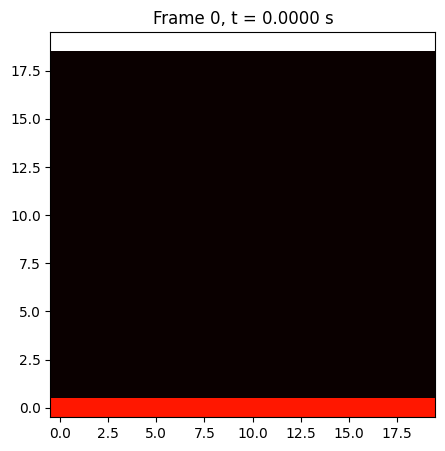

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation

# --- Parámetros físicos y espaciales ---
alpha = 0.01
Lx, Ly = 1.0, 1.0
Nx, Ny = 20, 20
dx = Lx / (Nx - 1)
dy = Ly / (Ny - 1)
dt = 0.0005
T_max = 0.1
Nt = int(T_max / dt)

lambda_x = alpha * dt / dx**2
lambda_y = alpha * dt / dy**2

# --- Condiciones iniciales y de frontera ---
def initial_condition():
    return np.zeros((Nx, Ny))

def apply_boundary_conditions(T):
    T[:, 0] = 20         # y = 0
    T[:, -1] = 50        # y = Ly
    T[0, :] = T[1, :]    # x = 0
    T[-1, :] = T[-2, :]  # x = Lx
    return T

# --- Método explícito con más pasos guardados ---
def metodo_explicito():
    T = initial_condition()
    T = apply_boundary_conditions(T)
    resultados = []
    guardar_cada = int(Nt / 60)  # guardamos 60 frames

    for n in range(Nt):
        T_new = T.copy()
        for i in range(1, Nx - 1):
            for j in range(1, Ny - 1):
                T_new[i, j] = (
                    T[i, j]
                    + lambda_x * (T[i+1, j] - 2*T[i, j] + T[i-1, j])
                    + lambda_y * (T[i, j+1] - 2*T[i, j] + T[i, j-1])
                )
        T = apply_boundary_conditions(T_new)
        if n % guardar_cada == 0:
            resultados.append(T.copy())
    return resultados

# --- Ejecutar ---
resultados = metodo_explicito()

# --- Animación con imshow ---
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(resultados[0].T, cmap='hot', origin='lower', vmin=0, vmax=50)
title = ax.set_title("")

def actualizar(frame):
    im.set_data(resultados[frame].T)
    title.set_text(f"Frame {frame}, t = {frame*dt*int(Nt/60):.4f} s")
    return im, title

ani = animation.FuncAnimation(fig, actualizar, frames=len(resultados), interval=150, blit=False)

# --- Guardar como GIF ---
ani.save("animacion_difusion.gif", writer='pillow', fps=10)
print("✅ Animación guardada como 'animacion_difusion.gif'")



### **Análisis de Convergencia (Método Explícito).**

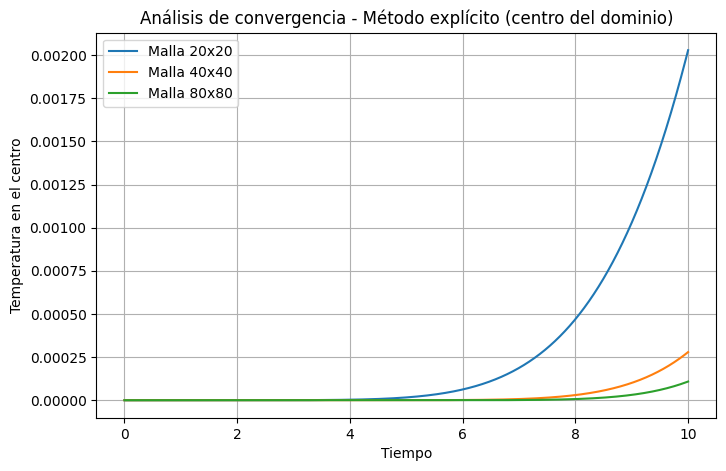

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Función: aplicar condiciones de frontera
def apply_boundary_conditions(T):
    T[:, 0] = 20        # y = 0 (Dirichlet)
    T[:, -1] = 50       # y = L (Dirichlet)
    T[0, :] = T[1, :]   # x = 0 (Neumann)
    T[-1, :] = T[-2, :] # x = L (Neumann)
    return T

# Función: obtener evolución en el centro para una malla
def get_central_temperature(Nx, Ny, alpha, dt, T_max):
    dx = Lx / (Nx - 1)
    dy = Ly / (Ny - 1)
    Nt = int(T_max / dt)

    lambda_x = alpha * dt / dx**2
    lambda_y = alpha * dt / dy**2

    x = np.linspace(0, Lx, Nx)
    y = np.linspace(0, Ly, Ny)
    X, Y = np.meshgrid(x, y)

    T = np.zeros((Nx, Ny))
    T = apply_boundary_conditions(T)
    centro = []

    i_c = Nx // 2
    j_c = Ny // 2

    for n in range(Nt):
        T_new = T.copy()
        for i in range(1, Nx - 1):
            for j in range(1, Ny - 1):
                T_new[i, j] = (
                    T[i, j]
                    + lambda_x * (T[i+1, j] - 2*T[i, j] + T[i-1, j])
                    + lambda_y * (T[i, j+1] - 2*T[i, j] + T[i, j-1])
                )
        T = apply_boundary_conditions(T_new)
        centro.append(T[i_c, j_c])  # Temperatura en el centro

    return centro

# Parámetros globales
Lx = Ly = 1.0
alpha = 0.00052
T_max = 10.0         # Más tiempo para que el calor se propague
dt = 0.0005

# Ejecutar para distintas mallas
mallados = [(20, 20), (40, 40), (80, 80)]
resultados = {}

for Nx, Ny in mallados:
    key = f"{Nx}x{Ny}"
    resultados[key] = get_central_temperature(Nx, Ny, alpha, dt, T_max)

# Graficar resultados
tiempos = np.linspace(0, T_max, len(list(resultados.values())[0]))
plt.figure(figsize=(8, 5))

for key, temp in resultados.items():
    plt.plot(tiempos, temp, label=f"Malla {key}")

plt.xlabel("Tiempo")
plt.ylabel("Temperatura en el centro")
plt.title("Análisis de convergencia - Método explícito (centro del dominio)")
plt.legend()
plt.grid(True)
plt.show()



### **Método Implícito.**

In [34]:
import numpy as np

def construir_matriz_A(N):
    A = -2 * np.eye(N)
    for i in range(N - 1):
        A[i, i+1] = 1
        A[i+1, i] = 1
    return A

def metodo_implicito_2D(Nx, Ny, alpha, dx, dy, dt, Nt):
    N = Nx * Ny
    Ix = np.eye(Nx)
    Iy = np.eye(Ny)
    Ax = construir_matriz_A(Nx)
    Ay = construir_matriz_A(Ny)

    lambda_x = alpha * dt / dx**2
    lambda_y = alpha * dt / dy**2

    # Matriz del sistema implícito
    M = np.eye(N) - lambda_x * np.kron(Iy, Ax) - lambda_y * np.kron(Ay, Ix)

    # Condición inicial y de frontera
    T = np.zeros((Nx, Ny))
    T[:, 0] = 20     # Borde izquierdo (y = 0)
    T[:, -1] = 50    # Borde derecho (y = Ly)

    resultados = {}
    for n in range(Nt):
        b = T.flatten()
        T_flat_next = np.linalg.solve(M, b)
        T = T_flat_next.reshape((Nx, Ny))

        # Reaplicar condiciones de frontera
        T[:, 0] = 20
        T[:, -1] = 50
        T[0, :] = T[1, :]
        T[-1, :] = T[-2, :]

        # Guardar resultado cada ciertos pasos para animación
        if n % max(1, Nt // 60) == 0:
            resultados[n] = T.copy()

    return resultados


✅ Animación guardada como 'animacion_implicito.gif'


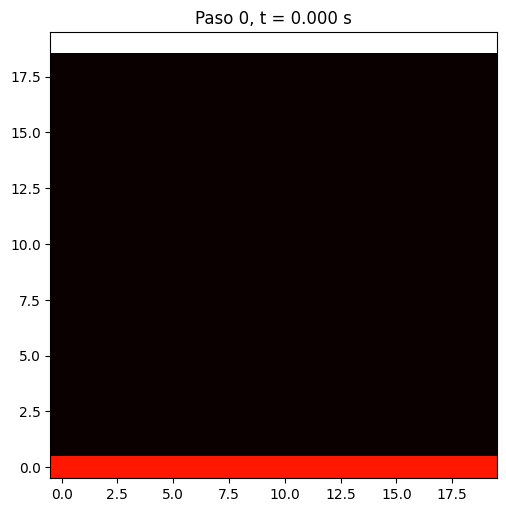

In [35]:
import matplotlib.pyplot as plt
from matplotlib import animation

# --- Crear figura y datos de tiempo ---
tiempos = sorted(resultados.keys())

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(resultados[tiempos[0]].T, cmap='hot', origin='lower', vmin=0, vmax=50)
title = ax.set_title("")

def actualizar(frame):
    T = resultados[tiempos[frame]]
    im.set_data(T.T)
    title.set_text(f"Paso {tiempos[frame]}, t = {tiempos[frame]*dt:.3f} s")
    return im, title

ani = animation.FuncAnimation(fig, actualizar, frames=len(tiempos), interval=150)

plt.tight_layout()

# --- Guardar como GIF ---
ani.save("animacion_implicito.gif", writer='pillow', fps=10)
print("✅ Animación guardada como 'animacion_implicito.gif'")


### **Método Implícito con Matrices Sparse.**

In [36]:
from scipy.sparse import kron, eye, csr_matrix
from scipy.sparse.linalg import spsolve
import numpy as np

def metodo_implicito_sparse_2D(Nx, Ny, alpha, dx, dy, dt, Nt):
    Ix = eye(Nx)
    Iy = eye(Ny)
    Ax = csr_matrix(construir_matriz_A(Nx))
    Ay = csr_matrix(construir_matriz_A(Ny))

    lambda_x = alpha * dt / dx**2
    lambda_y = alpha * dt / dy**2

    M = eye(Nx * Ny) - lambda_x * kron(Iy, Ax) - lambda_y * kron(Ay, Ix)

    T = np.zeros((Nx, Ny))
    T[:, 0] = 20
    T[:, -1] = 50

    resultados = {}

    for n in range(Nt):
        b = T.flatten()
        T_next_flat = spsolve(M, b)
        T = T_next_flat.reshape((Nx, Ny))

        T[:, 0] = 20
        T[:, -1] = 50
        T[0, :] = T[1, :]
        T[-1, :] = T[-2, :]

        # Guardar 60 pasos para animación
        if n % max(1, Nt // 60) == 0:
            resultados[n] = T.copy()

    return resultados



✅ Animación guardada como 'animacion_sparse.gif'


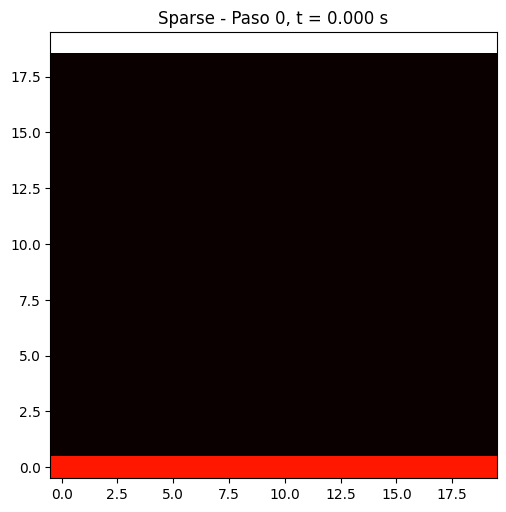

In [37]:
import matplotlib.pyplot as plt
from matplotlib import animation

# Ejecutar el método y generar resultados
resultados_sparse = metodo_implicito_sparse_2D(Nx, Ny, alpha, dx, dy, dt, Nt)
tiempos = sorted(resultados_sparse.keys())

# Crear animación con imshow
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(resultados_sparse[tiempos[0]].T, cmap='hot', origin='lower', vmin=0, vmax=50)
title = ax.set_title("")

def actualizar(frame):
    T = resultados_sparse[tiempos[frame]]
    im.set_data(T.T)
    title.set_text(f"Sparse - Paso {tiempos[frame]}, t = {tiempos[frame]*dt:.3f} s")
    return im, title

ani = animation.FuncAnimation(fig, actualizar, frames=len(tiempos), interval=100)

plt.tight_layout()

# Guardar como GIF
ani.save("animacion_sparse.gif", writer='pillow', fps=10)
print("✅ Animación guardada como 'animacion_sparse.gif'")



## **Solución Estacionaria.**

Una vez alcanzado un tiempo suficientemente grande, la temperatura $ T(x, y, t) $ tiende a una solución que ya no varía con el tiempo, denominada solución estacionaria.

En esta sección se resolverá directamente el problema estacionario, es decir, se buscará $ T(x, y) $ tal que:

$$
0 = 0.01(T_{xx} - T_{yy})
$$

para las condiciones de frontera dadas.

Se utilizarán diferentes técnicas para encontrar esta solución:
- Métodos iterativos (como Jacobi o Gauss-Seidel).
- Métodos implícitos directos.
- Métodos usando matrices sparse (con librerías y con implementación manual).

Se mostrarán las soluciones obtenidas para distintos tamaños de malla, comparando la eficiencia y precisión de los métodos.

### **Método Iterativo (Jacobi / Gauss-Seidel).**

### **Método Implícito.**

### **Método Implícito con Matrices Sparse.**

### **Método Implícito con Matrices Sparse (código propio).**